100%|██████████| 170M/170M [19:41<00:00, 144kB/s]


Epoch 1: Loss = 1.7058, Accuracy = 39.83%
Epoch 2: Loss = 1.4888, Accuracy = 47.90%
Epoch 3: Loss = 1.3902, Accuracy = 51.44%
Epoch 4: Loss = 1.3191, Accuracy = 54.20%
Epoch 5: Loss = 1.2566, Accuracy = 56.37%
Epoch 6: Loss = 1.2109, Accuracy = 57.93%
Epoch 7: Loss = 1.1639, Accuracy = 59.29%
Epoch 8: Loss = 1.1192, Accuracy = 61.28%
Epoch 9: Loss = 1.0753, Accuracy = 62.77%
Epoch 10: Loss = 1.0401, Accuracy = 63.97%
Epoch 1: Loss = 1.6370, Accuracy = 42.77%
Epoch 2: Loss = 1.4413, Accuracy = 49.70%
Epoch 3: Loss = 1.3462, Accuracy = 52.90%
Epoch 4: Loss = 1.2834, Accuracy = 55.36%
Epoch 5: Loss = 1.2134, Accuracy = 57.75%
Epoch 6: Loss = 1.1651, Accuracy = 59.70%
Epoch 7: Loss = 1.1106, Accuracy = 61.63%
Epoch 8: Loss = 1.0661, Accuracy = 63.31%
Epoch 9: Loss = 1.0199, Accuracy = 64.71%
Epoch 10: Loss = 0.9818, Accuracy = 66.14%


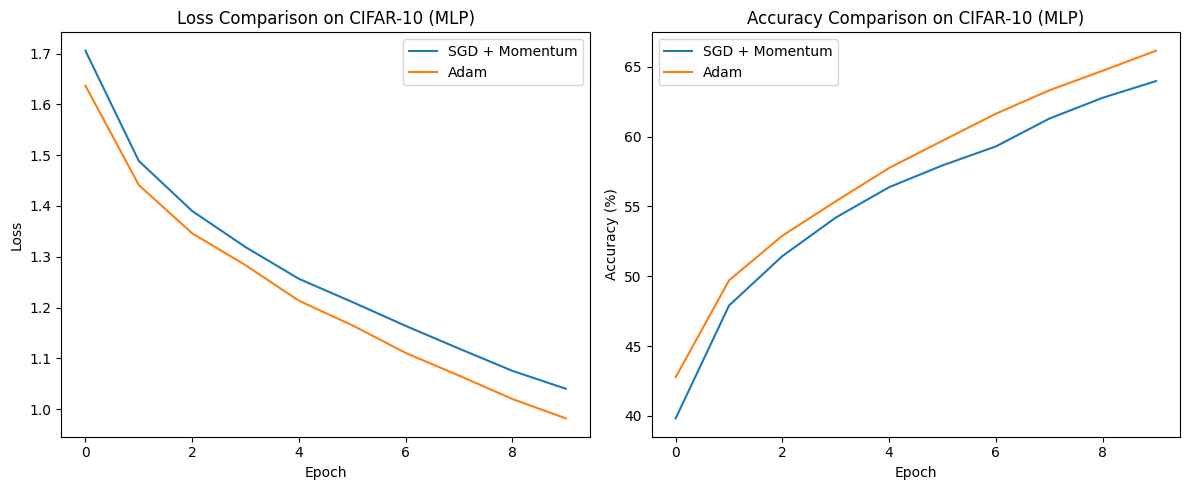

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=transform, download=True
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True
)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(self.flatten(x))

# Training function
def train(model, optimizer, epochs=10):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    losses, accuracies = [], []

    for epoch in range(epochs):
        total_loss = 0
        correct = total = 0
        model.train()

        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")

    return losses, accuracies

# SGD + Momentum
model_sgd = MLP()
sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
losses_sgd, acc_sgd = train(model_sgd, sgd)

# Adam
model_adam = MLP()
adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, acc_adam = train(model_adam, adam)

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_sgd, label="SGD + Momentum")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_sgd, label="SGD + Momentum")
plt.plot(acc_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()

plt.tight_layout()
plt.show()